# HR EDA

## Load data

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/raw/HRDataset_v14.csv")

In [3]:
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [4]:
df.describe()

,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,Zip,ManagerID,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences
count,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,303.000000,311.000000,311.000000,311.000000,311.000000,311.000000
mean,10156.000000,0.398714,0.810289,0.434084,2.392283,4.610932,2.977492,0.093248,69020.684887,0.334405,16.845659,6555.482315,14.570957,4.110000,3.890675,1.218650,0.414791,10.237942
std,89.922189,0.490423,0.943239,0.496435,1.794383,1.083487,0.587072,0.291248,25156.636930,0.472542,6.223419,16908.396884,8.078306,0.789938,0.909241,2.349421,1.294519,5.852596
min,10001.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,45046.000000,0.000000,1.000000,1013.000000,1.000000,1.120000,1.000000,0.000000,0.000000,1.000000
25%,10078.500000,0.000000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000,55501.500000,0.000000,18.000000,1901.500000,10.000000,3.690000,3.000000,0.000000,0.000000,5.000000
50%,10156.000000,0.000000,1.000000,0.000000,1.000000,5.000000,3.000000,0.000000,62810.000000,0.000000,19.000000,2132.000000,15.000000,4.280000,4.000000,0.000000,0.000000,10.000000
75%,10233.500000,1.000000,1.000000,1.000000,5.000000,5.000000,3.000000,0.000000,72036.000000,1.000000,20.000000,2355.000000,19.000000,4.700000,5.000000,0.000000,0.000000,15.000000
max,10311.000000,1.000000,4.000000,1.000000,5.000000,6.000000,4.000000,1.000000,250000.000000,1.000000,30.000000,98052.000000,39.000000,5.000000,5.000000,8.000000,6.000000,20.000000


In [5]:
df.dtypes

Employee_Name                  object
EmpID                           int64
MarriedID                       int64
MaritalStatusID                 int64
GenderID                        int64
EmpStatusID                     int64
DeptID                          int64
PerfScoreID                     int64
FromDiversityJobFairID          int64
Salary                          int64
Termd                           int64
PositionID                      int64
Position                       object
State                          object
Zip                             int64
DOB                            object
Sex                            object
MaritalDesc                    object
CitizenDesc                    object
HispanicLatino                 object
RaceDesc                       object
DateofHire                     object
DateofTermination              object
TermReason                     object
EmploymentStatus               object
Department                     object
ManagerName 

## Data cleaning

In [6]:
from pathlib import Path


df_clean = df.copy()

# Normalize string columns by trimming whitespace and collapsing repeated spaces where needed.
for column in df_clean.select_dtypes(include="object").columns:
    df_clean[column] = df_clean[column].astype("string").str.strip()

for column in ["Employee_Name", "Position", "Department"]:
    df_clean[column] = df_clean[column].str.replace(r"\s+", " ", regex=True)

# Standardize known inconsistent category labels.
df_clean["HispanicLatino"] = df_clean["HispanicLatino"].str.strip().str.title()

# Parse date fields into consistent datetime values before exporting.
date_columns = ["DOB", "DateofHire", "DateofTermination", "LastPerformanceReview_Date"]
for column in date_columns:
    df_clean[column] = pd.to_datetime(df_clean[column], errors="coerce", format="mixed")

# Use a nullable integer for ManagerID so missing values are preserved cleanly.
df_clean["ManagerID"] = df_clean["ManagerID"].round().astype("Int64")

processed_path = Path("../data/processed")
processed_path.mkdir(parents=True, exist_ok=True)
cleaned_path = processed_path / "HRDataset_v14_cleaned.csv"

df_clean.to_csv(cleaned_path, index=False, date_format="%Y-%m-%d")

# Use the cleaned frame for the rest of the notebook when rerun top to bottom.
df = df_clean

print(f"Saved cleaned dataset to: {cleaned_path}")
print(f"Rows: {df_clean.shape[0]}, Columns: {df_clean.shape[1]}")
print("\nPreview of cleaned values:")
display(df_clean[["Employee_Name", "Sex", "Department", "HispanicLatino", "DateofHire", "DateofTermination"]].head())

Saved cleaned dataset to: ../data/processed/HRDataset_v14_cleaned.csv
Rows: 311, Columns: 36

Preview of cleaned values:


,Employee_Name,Sex,Department,HispanicLatino,DateofHire,DateofTermination
0,"Adinolfi, Wilson K",M,Production,No,2011-07-05,NaT
1,"Ait Sidi, Karthikeyan",M,IT/IS,No,2015-03-30,2016-06-16
2,"Akinkuolie, Sarah",F,Production,No,2011-07-05,2012-09-24
3,"Alagbe,Trina",F,Production,No,2008-01-07,NaT
4,"Anderson, Carol",F,Production,No,2011-07-11,2016-09-06


## Workforce composition

### Gender

In [7]:
# gender distribution
df["Sex"].value_counts()

Sex
F    176
M    135
Name: count, dtype: Int64

In [8]:
# gender percentages
df["Sex"].value_counts(normalize=True) * 100

Sex
F    56.59164
M    43.40836
Name: proportion, dtype: Float64

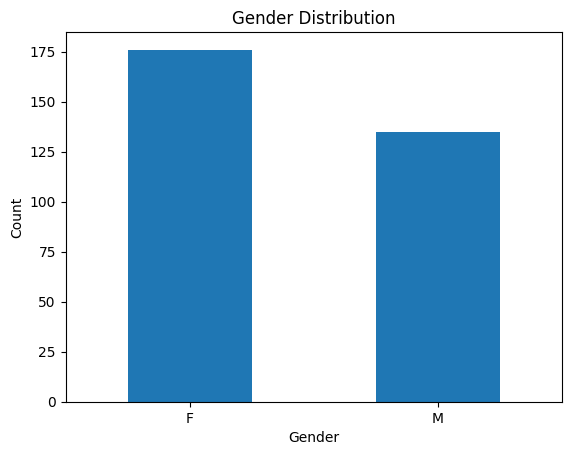

In [9]:
# visual gender distribution
import matplotlib.pyplot as plt


df["Sex"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### Race/ethnicity representation

In [10]:
# race/ethnicity distribution
df["RaceDesc"].value_counts()

RaceDesc
White                               187
Black or African American            80
Asian                                29
Two or more races                    11
American Indian or Alaska Native      3
Hispanic                              1
Name: count, dtype: Int64

In [11]:
# race/ethnicity percentages
df["RaceDesc"].value_counts(normalize=True) * 100

RaceDesc
White                               60.128617
Black or African American           25.723473
Asian                                9.324759
Two or more races                    3.536977
American Indian or Alaska Native      0.96463
Hispanic                             0.321543
Name: proportion, dtype: Float64

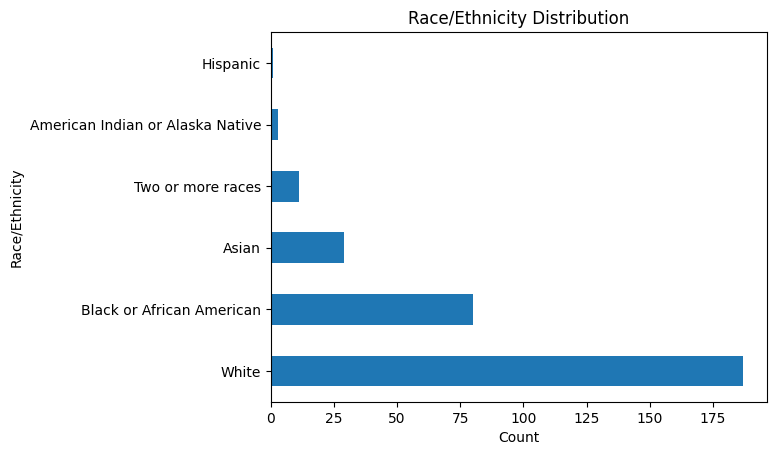

In [12]:
# visualize race/ethnicity distribution (horizontal bar chart)
df["RaceDesc"].value_counts().plot(kind="barh")
plt.title("Race/Ethnicity Distribution")
plt.xlabel("Count")
plt.ylabel("Race/Ethnicity")
plt.show()

### Marital status mix

In [13]:
# marital status distribution
df["MaritalDesc"].value_counts()

MaritalDesc
Single       137
Married      124
Divorced      30
Separated     12
Widowed        8
Name: count, dtype: Int64

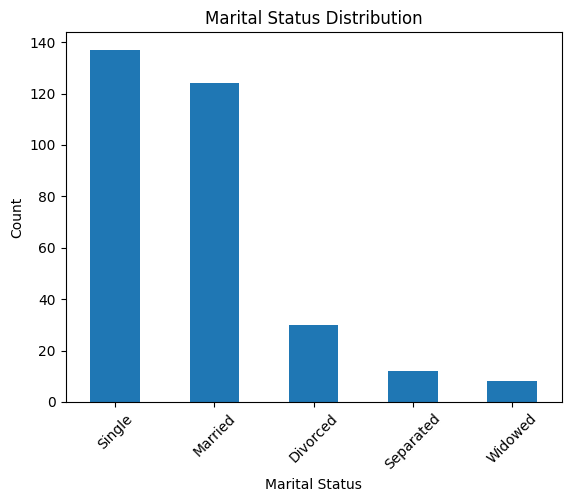

In [14]:
# visualize marital status distribution
df["MaritalDesc"].value_counts().plot(kind="bar")
plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [15]:
# marital status percentages
df["MaritalDesc"].value_counts(normalize=True) * 100

MaritalDesc
Single       44.051447
Married      39.871383
Divorced      9.646302
Separated     3.858521
Widowed       2.572347
Name: proportion, dtype: Float64

### Department composition

In [16]:
# department distribution
df["Department"].value_counts()

Department
Production              209
IT/IS                    50
Sales                    31
Software Engineering     11
Admin Offices             9
Executive Office          1
Name: count, dtype: Int64

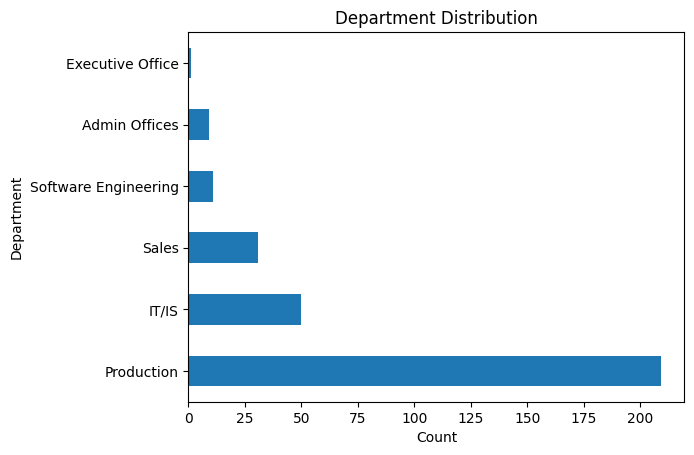

In [17]:
# visualize department distribution (horizontal bar chart)
df["Department"].value_counts().plot(kind="barh")
plt.title("Department Distribution")
plt.xlabel("Count")
plt.ylabel("Department")
plt.show()

In [18]:
# department percentages
df["Department"].value_counts(normalize=True) * 100

Department
Production              67.202572
IT/IS                    16.07717
Sales                    9.967846
Software Engineering     3.536977
Admin Offices            2.893891
Executive Office         0.321543
Name: proportion, dtype: Float64

### Manager span

In [19]:
# explore DateofHire and DateofTermination
df.DateofHire.astype("datetime64[ns]").max(), df.DateofTermination.astype("datetime64[ns]").max()

(Timestamp('2018-07-09 00:00:00'), Timestamp('2018-11-10 00:00:00'))

In [20]:
# explore ManagerID
df["ManagerID"].value_counts()

ManagerID
18    22
20    22
16    22
12    22
19    21
14    21
22    21
11    21
2     19
4     17
7     14
17    14
39    13
21    13
10     9
13     8
5      7
1      6
6      4
15     3
9      2
3      1
30     1
Name: count, dtype: Int64

In [21]:
# explore EmpID
df["EmpID"].value_counts()

EmpID
10026    1
10303    1
10005    1
10148    1
10041    1
        ..
10122    1
10159    1
10257    1
10111    1
10271    1
Name: count, Length: 311, dtype: int64

In [22]:
# see if any EmpIDs or Employee_names are ManagerIDs or ManagerNames
df["EmpID"].isin(df["ManagerID"]).sum(), df["Employee_Name"].isin(df["ManagerName"]).sum()

(np.int64(0), np.int64(0))

None of the rows are managers (that we can determine from the data)

### State distribution

In [23]:
# state distribution
df["State"].value_counts()

State
MA    276
CT      6
TX      3
VT      2
UT      1
AZ      1
ND      1
OR      1
MT      1
NV      1
ID      1
KY      1
NC      1
FL      1
GA      1
CO      1
NY      1
PA      1
RI      1
NH      1
TN      1
IN      1
OH      1
CA      1
WA      1
AL      1
VA      1
ME      1
Name: count, dtype: Int64

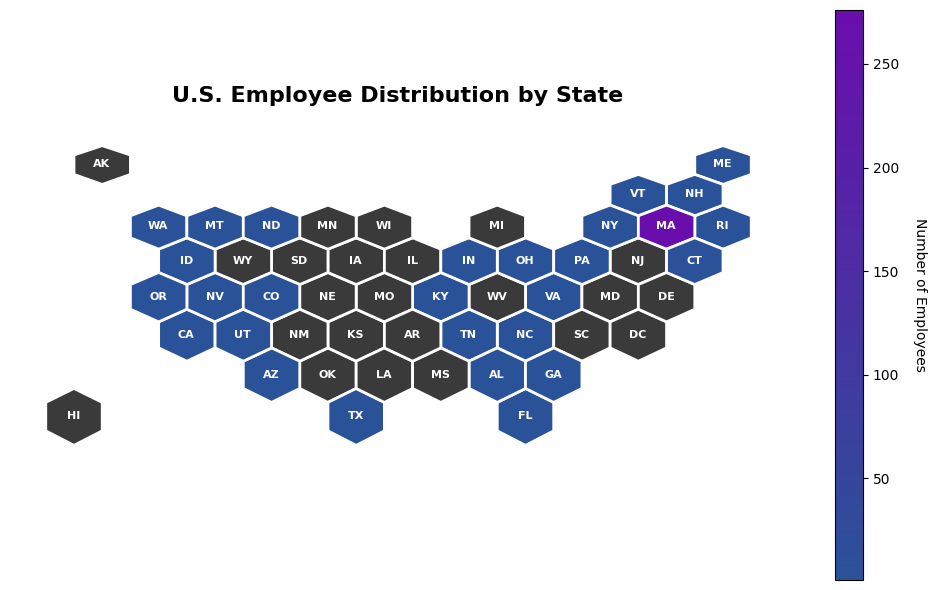

In [24]:
# U.S. heatmap of employee distribution by state
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


url = "https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/us_states_hexgrid.geojson.json"
geoData = gpd.read_file(url)

# Get state counts
state_counts = df["State"].value_counts().reset_index()
state_counts.columns = ["State", "Count"]

# Create a dict for fast lookup
state_count_dict = dict(zip(state_counts["State"], state_counts["Count"]))

# Add count column to geodata
geoData["count"] = geoData["iso3166_2"].map(state_count_dict).fillna(0)

# Build a blue -> dark purple gradient only for non-zero values
blue_purple_cmap = mcolors.LinearSegmentedColormap.from_list(
    "blue_purple", ["#2a5298", "#6a0dad"]
)

# Normalize across non-zero values only
non_zero_counts = geoData.loc[geoData["count"] > 0, "count"]
norm = Normalize(vmin=non_zero_counts.min(), vmax=non_zero_counts.max())

# The colorbar should reflect the non-zero gradient
sm = ScalarMappable(cmap=blue_purple_cmap, norm=norm)

# Plot
fig, ax = plt.subplots(1, figsize=(10, 6))

ZERO_COLOR = "#3a3a3a"  # dark gray for empty states

for idx, row in geoData.iterrows():
    if row["count"] == 0:
        color = ZERO_COLOR
    else:
        color = blue_purple_cmap(norm(row["count"]))

    gpd.GeoSeries([row["geometry"]]).plot(ax=ax, color=color, edgecolor="white", linewidth=2)

    plt.text(
        row["geometry"].centroid.x,
        row["geometry"].centroid.y,
        row["iso3166_2"],
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="white"
    )

# Add colorbar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Number of Employees", rotation=270, labelpad=20)

plt.title("U.S. Employee Distribution by State", fontsize=16, fontweight="bold", pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()

Which departments are least diverse?

In [25]:
df["Sex"].value_counts()

Sex
F    176
M    135
Name: count, dtype: Int64

In [26]:
# which departments have the least diversity in terms of gender ("Sex") and race/ethnicity ("RaceDesc")?
dept_diversity = df.groupby("Department").agg(
    total_employees=("EmpID", "count"),
    male_employees=("Sex", lambda x: (x == "M").sum()),
    female_employees=("Sex", lambda x: (x == "F").sum()),
    white_employees=("RaceDesc", lambda x: (x == "White").sum()),
    black_employees=("RaceDesc", lambda x: (x == "Black or African American").sum()),
    asian_employees=("RaceDesc", lambda x: (x == "Asian").sum())
)

dept_diversity["male_percentage"] = dept_diversity["male_employees"] / dept_diversity["total_employees"] * 100
dept_diversity["female_percentage"] = dept_diversity["female_employees"] / dept_diversity["total_employees"] * 100
dept_diversity["white_percentage"] = dept_diversity["white_employees"] / dept_diversity["total_employees"] * 100
dept_diversity["black_percentage"] = dept_diversity["black_employees"] / dept_diversity["total_employees"] * 100
dept_diversity["asian_percentage"] = dept_diversity["asian_employees"] / dept_diversity["total_employees"] * 100

In [27]:
dept_diversity.sort_values("male_percentage", ascending=False)[["male_percentage", "female_percentage"]]

,male_percentage,female_percentage
Department,,
IT/IS,56.000000,44.000000
Sales,51.612903,48.387097
Software Engineering,45.454545,54.545455
Production,39.712919,60.287081
Admin Offices,33.333333,66.666667
Executive Office,0.000000,100.000000


In [28]:
dept_diversity.sort_values("white_percentage", ascending=False)[["white_percentage", "black_percentage", "asian_percentage"]]

,white_percentage,black_percentage,asian_percentage
Department,,,
Executive Office,100.000000,0.000000,0.000000
Production,64.114833,21.531100,10.047847
IT/IS,58.000000,30.000000,12.000000
Software Engineering,45.454545,45.454545,9.090909
Sales,45.161290,32.258065,3.225806
Admin Offices,44.444444,55.555556,0.000000


Does diversity vary by recruiting source?

In [29]:
# does diversity vary by recruiting source ("RecruitmentSource")?
recruitment_diversity = df.groupby("RecruitmentSource").agg(
    total_employees=("EmpID", "count"),
    male_employees=("Sex", lambda x: (x == "M").sum()),
    female_employees=("Sex", lambda x: (x == "F").sum()),
    white_employees=("RaceDesc", lambda x: (x == "White").sum()),
    black_employees=("RaceDesc", lambda x: (x == "Black or African American").sum()),
    asian_employees=("RaceDesc", lambda x: (x == "Asian").sum())
)
recruitment_diversity["male_percentage"] = recruitment_diversity["male_employees"] / recruitment_diversity["total_employees"] * 100
recruitment_diversity["female_percentage"] = recruitment_diversity["female_employees"] / recruitment_diversity["total_employees"] * 100
recruitment_diversity["white_percentage"] = recruitment_diversity["white_employees"] / recruitment_diversity["total_employees"] * 100
recruitment_diversity["black_percentage"] = recruitment_diversity["black_employees"] / recruitment_diversity["total_employees"] * 100
recruitment_diversity["asian_percentage"] = recruitment_diversity["asian_employees"] / recruitment_diversity["total_employees"] * 100

In [30]:
recruitment_diversity.sort_values("male_percentage", ascending=False)[["male_percentage", "female_percentage"]]

,male_percentage,female_percentage
RecruitmentSource,,
On-line Web application,100.000000,0.000000
Employee Referral,64.516129,35.483871
Website,53.846154,46.153846
Other,50.000000,50.000000
Diversity Job Fair,48.275862,51.724138
Indeed,42.528736,57.471264
LinkedIn,42.105263,57.894737
Google Search,32.653061,67.346939
CareerBuilder,30.434783,69.565217


In [31]:
recruitment_diversity.sort_values("white_percentage", ascending=False)[["white_percentage", "black_percentage", "asian_percentage"]]

,white_percentage,black_percentage,asian_percentage
RecruitmentSource,,,
On-line Web application,100.000000,0.000000,0.000000
Other,100.000000,0.000000,0.000000
Employee Referral,80.645161,16.129032,3.225806
Google Search,71.428571,8.163265,14.285714
CareerBuilder,69.565217,21.739130,8.695652
Indeed,62.068966,19.540230,11.494253
LinkedIn,61.842105,21.052632,10.526316
Website,53.846154,30.769231,7.692308
Diversity Job Fair,0.000000,100.000000,0.000000


## Attrition analysis

### Overall rate

In [32]:
# overall attrition rate
attrition_rate = (df["Termd"] == 1).mean() * 100
print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

Overall Attrition Rate: 33.44%


In [33]:
# attrition rate by department
dept_attrition = df.groupby("Department")["Termd"].mean() * 100
dept_attrition.sort_values(ascending=False)

Department
Production              39.712919
Software Engineering    36.363636
Admin Offices           22.222222
IT/IS                   20.000000
Sales                   16.129032
Executive Office         0.000000
Name: Termd, dtype: float64

In [34]:
# attrition rate by manager
manager_attrition = df.groupby("ManagerName")["Termd"].mean() * 100
manager_attrition.sort_values(ascending=False).head(10)

ManagerName
Webster Butler     61.904762
Amy Dunn           61.904762
Kissy Sullivan     54.545455
Simon Roup         47.058824
Michael Albert     40.909091
Elijiah Gray       36.363636
Debra Houlihan     33.333333
Alex Sweetwater    33.333333
Janet King         31.578947
David Stanley      28.571429
Name: Termd, dtype: float64

In [35]:
# attrition rate by recruitment source
recruitment_attrition = df.groupby("RecruitmentSource")["Termd"].mean() * 100
recruitment_attrition.sort_values(ascending=False)

RecruitmentSource
On-line Web application    100.000000
Google Search               61.224490
Diversity Job Fair          55.172414
Other                       50.000000
CareerBuilder               47.826087
Indeed                      24.137931
LinkedIn                    23.684211
Employee Referral           16.129032
Website                      7.692308
Name: Termd, dtype: float64

In [36]:
# attrition rate by salary band
# make up salary band categories based on Salary
df["SalaryBand"] = pd.cut(df["Salary"], bins=[0, 50000, 100000, 150000, 200000, np.inf], labels=["0-50k", "50k-100k", "100k-150k", "150k-200k", "200k+"])
salary_attrition = df.groupby("SalaryBand", observed=True)["Termd"].mean() * 100
salary_attrition.sort_values(ascending=False)

SalaryBand
100k-150k    50.000000
0-50k        45.161290
50k-100k     31.764706
150k-200k     0.000000
200k+         0.000000
Name: Termd, dtype: float64

In [37]:
# attrition by engagement quartiles
df["EngagementQuartile"] = pd.qcut(df["EngagementSurvey"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])
engagement_attrition = df.groupby("EngagementQuartile", observed=True)["Termd"].mean() * 100
engagement_attrition.sort_values(ascending=False)

EngagementQuartile
Q1    37.974684
Q4    35.616438
Q3    30.487805
Q2    29.870130
Name: Termd, dtype: float64

In [38]:
# attrition rate by performance
performance_attrition = df.groupby("PerformanceScore")["Termd"].mean() * 100
performance_attrition.sort_values(ascending=False)

PerformanceScore
Needs Improvement    55.555556
PIP                  38.461538
Fully Meets          33.333333
Exceeds              21.621622
Name: Termd, dtype: float64

## Engagement satisfaction drivers

In [39]:
# Targets: EngagementSurvey, EmpSatisfaction
# Explore relationships with: salary, absences, lateness, performance, special projects, department, manager
# consider correlation matrix, ANOVA, t-tests, and regression analysis
from scipy.stats import pearsonr, f_oneway, ttest_ind
import statsmodels.api as sm
from statsmodels.formula.api import ols


targets = ["EngagementSurvey", "EmpSatisfaction"]
features = ["Salary", "Absences", "DaysLateLast30", "PerformanceScore", "SpecialProjectsCount", "Department", "ManagerName"]

for target in targets:
    print(f"\nAnalyzing {target} relationships:")
    for feature in features:
        if df[feature].dtype in [np.float64, np.int64]:  # numeric features
            corr, p_value = pearsonr(df[feature], df[target])
            print(f"  {feature} (numeric): Pearson r={corr:.2f}, p={p_value:.3f}")
        else:  # categorical features
            groups = [df[df[feature] == cat][target] for cat in df[feature].unique()]
            f_stat, p_value = f_oneway(*groups)
            print(f"  {feature} (categorical): ANOVA F={f_stat:.2f}, p={p_value:.3f}")


Analyzing EngagementSurvey relationships:
  Salary (numeric): Pearson r=0.06, p=0.253
  Absences (numeric): Pearson r=-0.01, p=0.878
  DaysLateLast30 (numeric): Pearson r=-0.59, p=0.000
  PerformanceScore (categorical): ANOVA F=69.16, p=0.000
  SpecialProjectsCount (numeric): Pearson r=0.01, p=0.816
  Department (categorical): ANOVA F=1.31, p=0.259
  ManagerName (categorical): ANOVA F=0.90, p=0.589

Analyzing EmpSatisfaction relationships:
  Salary (numeric): Pearson r=0.06, p=0.270
  Absences (numeric): Pearson r=0.08, p=0.186
  DaysLateLast30 (numeric): Pearson r=-0.24, p=0.000
  PerformanceScore (categorical): ANOVA F=12.45, p=0.000
  SpecialProjectsCount (numeric): Pearson r=0.03, p=0.552
  Department (categorical): ANOVA F=0.79, p=0.556
  ManagerName (categorical): ANOVA F=0.90, p=0.588


## Performance analytics

In [40]:
# targets: PerformanceScore, PerfScoreID
# Explore performance distribution, performance by manager, recruitment source, department, and engagement
performance_df = df[["PerformanceScore", "PerfScoreID", "ManagerName", "RecruitmentSource", "Department", "EngagementSurvey"]]

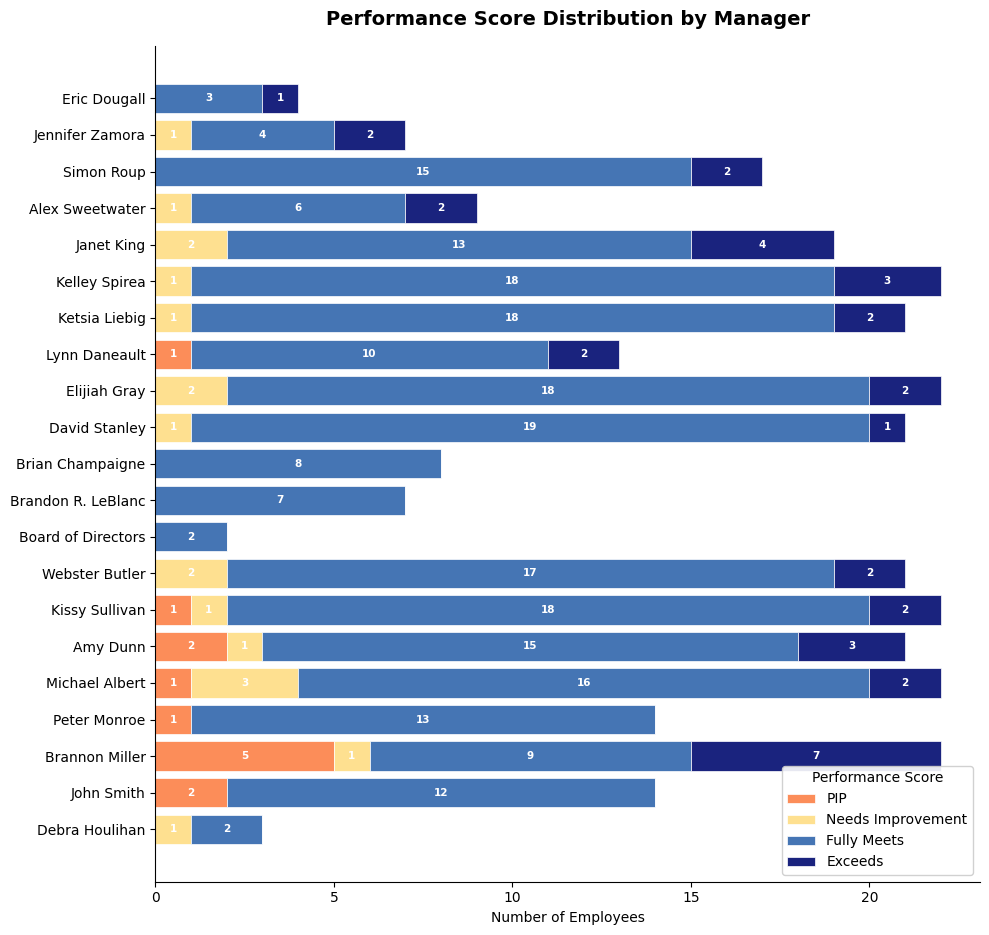

In [41]:
# stacked bar chart of performance score distribution by manager
# where height represents count of PerfScoreID per manager and color represents PerformanceScore
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


# Map PerfScoreID to label for legend clarity
perf_labels = {1: "PIP", 2: "Needs Improvement", 3: "Fully Meets", 4: "Exceeds"}
perf_colors = {1: "#fc8d59", 2: "#fee090", 3: "#4575b4", 4: "#1a237e"}

# Pivot: managers as rows, PerfScoreID as columns, values = counts
pivot = (
    performance_df.groupby(["ManagerName", "PerfScoreID"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=sorted(perf_colors.keys()), fill_value=0)  # fill_value=0 instead of NaN
)

# Sort managers by weighted average performance (best at top)
pivot["avg"] = (pivot * pivot.columns).sum(axis=1) / pivot.sum(axis=1)
pivot = pivot.sort_values("avg", ascending=True).drop(columns="avg")

# Plot
fig, ax = plt.subplots(figsize=(10, max(6, len(pivot) * 0.45)))

bottoms = np.zeros(len(pivot))
for score_id in pivot.columns:
    values = pivot[score_id].values
    ax.barh(
        pivot.index,
        values,
        left=bottoms,
        color=perf_colors[score_id],
        label=perf_labels[score_id],
        edgecolor="white",
        linewidth=0.5
    )
    # Label segments if wide enough
    for i, (val, left) in enumerate(zip(values, bottoms)):
        if val > 0:
            ax.text(left + val / 2, i, str(val), ha="center", va="center",
                    fontsize=7.5, color="white", fontweight="bold")
    bottoms += values

ax.set_xlabel("Number of Employees")
ax.set_title("Performance Score Distribution by Manager", fontsize=14, fontweight="bold", pad=15)
ax.legend(loc="lower right", title="Performance Score", framealpha=0.9)
ax.set_xlim(0, pivot.sum(axis=1).max() * 1.05)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

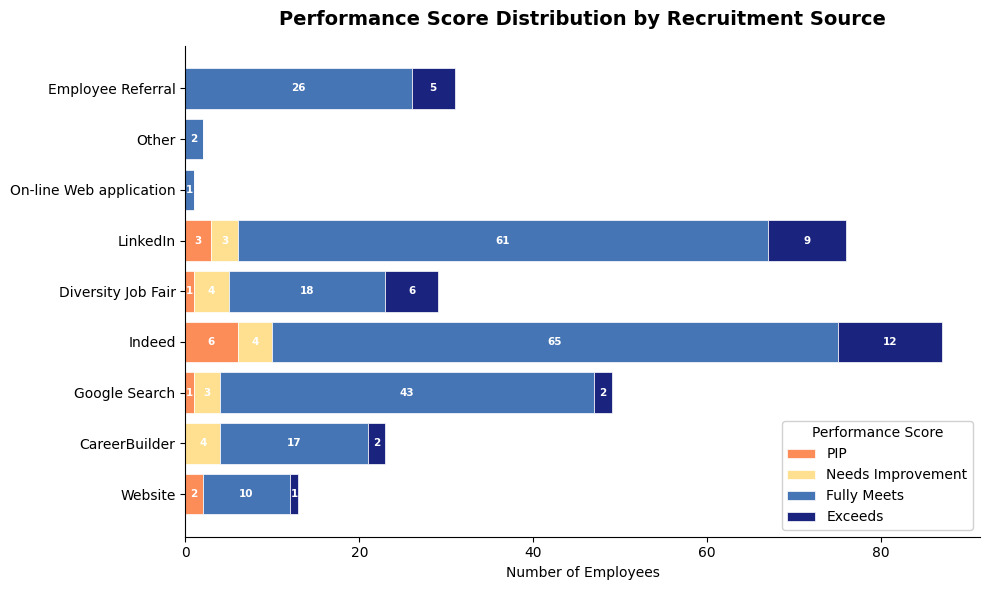

In [42]:
# now do the same for recruitment source
pivot = (
    performance_df.groupby(["RecruitmentSource", "PerfScoreID"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=sorted(perf_colors.keys()), fill_value=0)  # fill_value=0 instead of NaN
)

pivot["avg"] = (pivot * pivot.columns).sum(axis=1) / pivot.sum(axis=1)
pivot = pivot.sort_values("avg", ascending=True).drop(columns="avg")

fig, ax = plt.subplots(figsize=(10, max(6, len(pivot) * 0.45)))
bottoms = np.zeros(len(pivot))
for score_id in pivot.columns:
    values = pivot[score_id].values
    ax.barh(
        pivot.index,
        values,
        left=bottoms,
        color=perf_colors[score_id],
        label=perf_labels[score_id],
        edgecolor="white",
        linewidth=0.5
    )
    for i, (val, left) in enumerate(zip(values, bottoms)):
        if val > 0:
            ax.text(left + val / 2, i, str(val), ha="center", va="center",
                    fontsize=7.5, color="white", fontweight="bold")
    bottoms += values

ax.set_xlabel("Number of Employees")
ax.set_title("Performance Score Distribution by Recruitment Source", fontsize=14, fontweight="bold", pad=15)
ax.legend(loc="lower right", title="Performance Score", framealpha=0.9)
ax.set_xlim(0, pivot.sum(axis=1).max() * 1.05)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

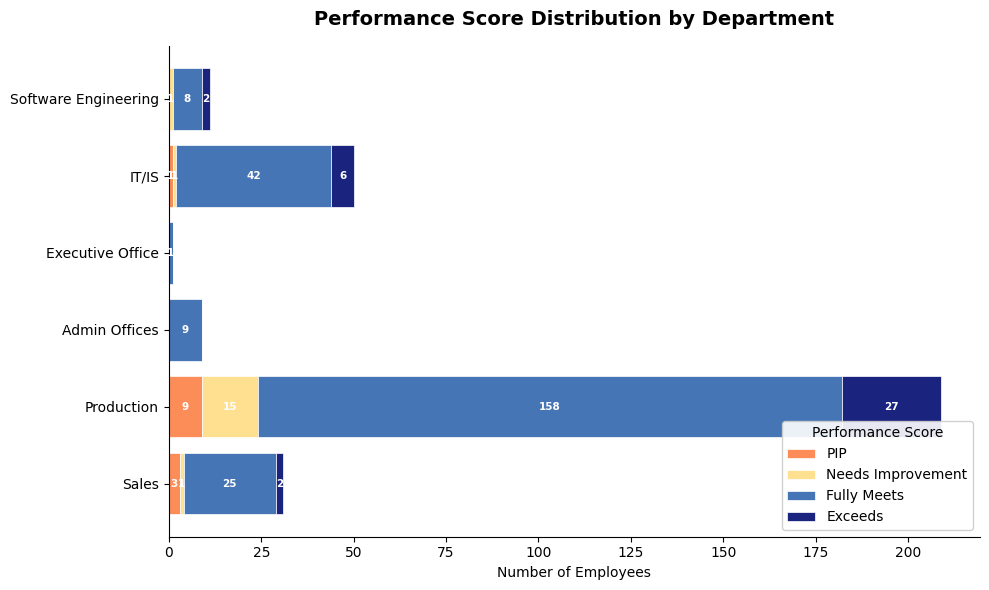

In [43]:
# now do the same for department
pivot = (
    performance_df.groupby(["Department", "PerfScoreID"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=sorted(perf_colors.keys()), fill_value=0)  # fill_value=0 instead of NaN
)

pivot["avg"] = (pivot * pivot.columns).sum(axis=1) / pivot.sum(axis=1)
pivot = pivot.sort_values("avg", ascending=True).drop(columns="avg")

fig, ax = plt.subplots(figsize=(10, max(6, len(pivot) * 0.45)))
bottoms = np.zeros(len(pivot))
for score_id in pivot.columns:
    values = pivot[score_id].values
    ax.barh(
        pivot.index,
        values,
        left=bottoms,
        color=perf_colors[score_id],
        label=perf_labels[score_id],
        edgecolor="white",
        linewidth=0.5
    )
    for i, (val, left) in enumerate(zip(values, bottoms)):
        if val > 0:
            ax.text(left + val / 2, i, str(val), ha="center", va="center",
                    fontsize=7.5, color="white", fontweight="bold")
    bottoms += values

ax.set_xlabel("Number of Employees")
ax.set_title("Performance Score Distribution by Department", fontsize=14, fontweight="bold", pad=15)
ax.legend(loc="lower right", title="Performance Score", framealpha=0.9)
ax.set_xlim(0, pivot.sum(axis=1).max() * 1.05)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

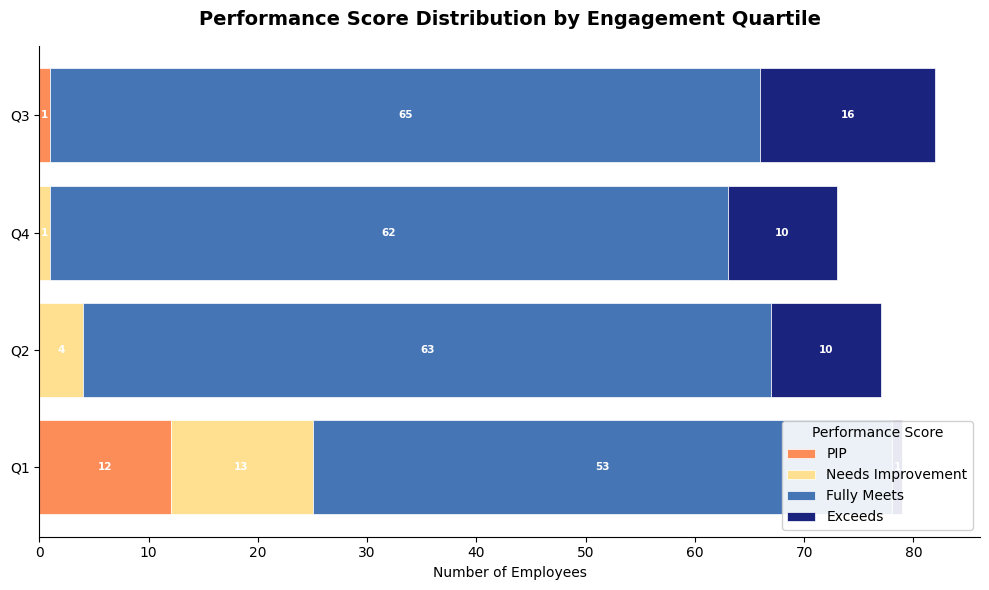

In [44]:
# now do the same for engagement quartiles
pivot = (
    df.groupby(["EngagementQuartile", "PerfScoreID"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=sorted(perf_colors.keys()), fill_value=0)  # fill_value=0 instead of NaN
)

pivot["avg"] = (pivot * pivot.columns).sum(axis=1) / pivot.sum(axis=1)
pivot = pivot.sort_values("avg", ascending=True).drop(columns="avg")

fig, ax = plt.subplots(figsize=(10, max(6, len(pivot) * 0.45)))
bottoms = np.zeros(len(pivot))
for score_id in pivot.columns:
    values = pivot[score_id].values
    ax.barh(
        pivot.index,
        values,
        left=bottoms,
        color=perf_colors[score_id],
        label=perf_labels[score_id],
        edgecolor="white",
        linewidth=0.5
    )
    for i, (val, left) in enumerate(zip(values, bottoms)):
        if val > 0:
            ax.text(left + val / 2, i, str(val), ha="center", va="center",
                    fontsize=7.5, color="white", fontweight="bold")
    bottoms += values

ax.set_xlabel("Number of Employees")
ax.set_title("Performance Score Distribution by Engagement Quartile", fontsize=14, fontweight="bold", pad=15)
ax.legend(loc="lower right", title="Performance Score", framealpha=0.9)
ax.set_xlim(0, pivot.sum(axis=1).max() * 1.05)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Recruiting Funnel / Hiring Outcomes

In [45]:
df[["PerfScoreID", "EngagementSurvey", "Absences", "DaysLateLast30"]].describe()

,PerfScoreID,EngagementSurvey,Absences,DaysLateLast30
count,311.000000,311.000000,311.000000,311.000000
mean,2.977492,4.110000,10.237942,0.414791
std,0.587072,0.789938,5.852596,1.294519
min,1.000000,1.120000,1.000000,0.000000
25%,3.000000,3.690000,5.000000,0.000000
50%,3.000000,4.280000,10.000000,0.000000
75%,3.000000,4.700000,15.000000,0.000000
max,4.000000,5.000000,20.000000,6.000000


In [46]:
# target: quality of hire based on performance (PerfScoreID: 3, 2, 1, or 0), engagement, retained, and low absences/lateness
# formulate quality of hire metric (ensure metric is between 0 and 1)
def calculate_quality_of_hire(row):
    perf_score_weight = row["PerfScoreID"] / 4  # normalize to 0-1
    engagement_weight = row["EngagementSurvey"] / 5  # normalize to 0-1
    retention_weight = 1 - row["Termd"]  # 1 if retained, 0 if terminated
    absence_weight = (max(df["Absences"]) - row["Absences"]) / max(df["Absences"]) if max(df["Absences"]) != 0 else 0  # more absences reduces score
    lateness_weight = max(0, (30 - row["DaysLateLast30"])) / 30  # more lateness reduces score

    quality_score = (perf_score_weight * 0.4 +
                     engagement_weight * 0.3 +
                     retention_weight * 0.2 +
                     (absence_weight + lateness_weight) / 2 * 0.1)

    return quality_score

df["QualityOfHire"] = df.apply(calculate_quality_of_hire, axis=1)
df.QualityOfHire.describe()

count    311.000000
mean       0.751182
std        0.139953
min        0.322300
25%        0.648200
50%        0.787000
75%        0.855250
max        0.979500
Name: QualityOfHire, dtype: float64

In [47]:
# which recruiting channels yield the highest quality of hire on average?
df.groupby("RecruitmentSource")["QualityOfHire"].mean().sort_values(ascending=False)

RecruitmentSource
Employee Referral          0.809137
Website                    0.790928
LinkedIn                   0.774393
Indeed                     0.761165
Other                      0.750500
CareerBuilder              0.713987
Diversity Job Fair         0.704906
On-line Web application    0.697500
Google Search              0.696218
Name: QualityOfHire, dtype: float64

## Manager effectiveness analysis

In [48]:
# group by manager ID and find average quality of hire for each manager
manager_quality = df.groupby("ManagerID")["QualityOfHire"].mean().sort_values(ascending=False)
manager_quality.head(10)

ManagerID
3     0.890000
9     0.878650
6     0.877600
13    0.812275
5     0.800948
18    0.794830
21    0.787000
7     0.786229
19    0.776825
2     0.772242
Name: QualityOfHire, dtype: float64

In [49]:
# group by manager ID and find average engagement score for each manager
manager_engagement = df.groupby("ManagerID")["EngagementSurvey"].mean().sort_values(ascending=False)
manager_engagement.head(10)

ManagerID
3     5.000000
9     4.915000
6     4.585000
18    4.484545
39    4.367692
1     4.240000
4     4.225294
2     4.182105
14    4.150952
22    4.116190
Name: EngagementSurvey, dtype: float64

In [50]:
# group by manager ID and find average attrition rate for each manager
manager_attrition = df.groupby("ManagerID")["Termd"].mean() * 100
manager_attrition.sort_values(ascending=False).head(10)

ManagerID
39    100.000000
30    100.000000
11     61.904762
20     54.545455
4      47.058824
22     38.095238
16     36.363636
15     33.333333
1      33.333333
10     33.333333
Name: Termd, dtype: float64

In [51]:
# group by manager ID and find mode performance score for each manager
manager_performance = df.groupby("ManagerID")["PerformanceScore"].agg(lambda x: x.mode()[0])
manager_performance.sort_values(ascending=False).head(10)

ManagerID
1     Fully Meets
14    Fully Meets
30    Fully Meets
22    Fully Meets
21    Fully Meets
20    Fully Meets
19    Fully Meets
18    Fully Meets
17    Fully Meets
16    Fully Meets
Name: PerformanceScore, dtype: string

In [52]:
# group by manager ID and calculate average absences
manager_absences = df.groupby("ManagerID")["Absences"].mean().sort_values(ascending=False)
manager_absences.head(10)

ManagerID
30    16.000000
39    13.538462
17    13.357143
13    12.500000
18    11.363636
22    10.666667
20    10.590909
7     10.571429
14    10.380952
2     10.210526
Name: Absences, dtype: float64

In [53]:
# group by manager ID and find average satisfaction score
manager_satisfaction = df.groupby("ManagerID")["EmpSatisfaction"].mean().sort_values(ascending=False)
manager_satisfaction.head(10)

ManagerID
30    5.000000
15    4.333333
5     4.285714
10    4.222222
19    4.095238
39    4.076923
21    4.076923
22    4.000000
13    4.000000
3     4.000000
Name: EmpSatisfaction, dtype: float64

## Mobility signals

In [54]:
# use special projects, salary relative to department, and tenure as indicators for promoted employees (there is no explicit promotion data)
# tenure is calculated as difference between DateofHire and DateofTermination (or current date, defined as 12/31/2018, if still employed)
from datetime import datetime


def calculate_tenure(row):
    hire_date = pd.to_datetime(row["DateofHire"], errors="coerce")
    if pd.isna(hire_date):
        return np.nan
    if row["Termd"] == 1:
        term_date = pd.to_datetime(row["DateofTermination"], errors="coerce")
        if pd.isna(term_date):
            return np.nan
        tenure = (term_date - hire_date).days / 365.25
    else:
        current_date = datetime(2018, 12, 31)
        tenure = (current_date - hire_date).days / 365.25
    return tenure

df["Tenure"] = df.apply(calculate_tenure, axis=1)
df.Tenure.describe()

count    311.000000
mean       4.716833
std        2.160778
min        0.071184
25%        3.577002
50%        4.610541
75%        6.151951
max       12.974675
Name: Tenure, dtype: float64

In [55]:
# use special projects, salary relative to department, and tenure as indicators for promoted employees (there is no explicit promotion data)
df["SalaryRelativeToDept"] = df["Salary"] / df.groupby("Department")["Salary"].transform("mean")
df[["SpecialProjectsCount", "SalaryRelativeToDept", "Tenure"]].describe()

,SpecialProjectsCount,SalaryRelativeToDept,Tenure
count,311.000000,311.000000,311.000000
mean,1.218650,1.000000,4.716833
std,2.349421,0.233936,2.160778
min,0.000000,0.516954,0.071184
25%,0.000000,0.877674,3.577002
50%,0.000000,0.983078,4.610541
75%,0.000000,1.067654,6.151951
max,8.000000,2.843869,12.974675


In [56]:
# use special projects, salary relative to department, and tenure as indicators for promoted employees (there is no explicit promotion data)
# create promotion indicator based on being in top 10% of special projects, salary relative to department, and tenure
df["Promoted"] = ((df["SpecialProjectsCount"] >= df["SpecialProjectsCount"].quantile(0.75)) &
                  (df["SalaryRelativeToDept"] >= df["SalaryRelativeToDept"].quantile(0.75)) &
                  (df["Tenure"] >= df["Tenure"].quantile(0.75))).astype(int)
df["Promoted"].value_counts()

Promoted
0    294
1     17
Name: count, dtype: int64

## DEI analytics

In [57]:
df.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences', 'SalaryBand', 'EngagementQuartile', 'QualityOfHire',
       'Tenure', 'SalaryRelativeToDept', 'Promoted'],
      dtype='object')

In [58]:
# consider chi-square for pay gap analysis over gender and race separately
from scipy.stats import chi2_contingency
import pandas as pd

pay_df = df[["Sex", "RaceDesc", "SalaryBand"]].dropna()

def run_chi_square(data, group_col):
    contingency = pd.crosstab(data[group_col], data["SalaryBand"])
    chi2, p, dof, expected = chi2_contingency(contingency)

    print(f"--- Pay Gap Analysis by {group_col} ---")
    print(f"  Chi-square statistic : {chi2:.4f}")
    print(f"  Degrees of freedom   : {dof}")
    print(f"  P-value              : {p:.4f}")
    print(f"  Result               : {'Significant association ⚠️' if p < 0.05 else 'No significant association ✓'}")
    print()
    print("  Observed counts:")
    print(contingency.to_string(index=True))
    print()
    print("  Expected counts:")
    print(pd.DataFrame(expected.round(1), index=contingency.index, columns=contingency.columns).to_string())
    print()

run_chi_square(pay_df, "Sex")
run_chi_square(pay_df, "RaceDesc")

--- Pay Gap Analysis by Sex ---
  Chi-square statistic : 2.4478
  Degrees of freedom   : 4
  P-value              : 0.6540
  Result               : No significant association ✓

  Observed counts:
SalaryBand  0-50k  50k-100k  100k-150k  150k-200k  200k+
Sex                                                     
F              18       145          9          2      2
M              13       110          9          3      0

  Expected counts:
SalaryBand  0-50k  50k-100k  100k-150k  150k-200k  200k+
Sex                                                     
F            17.5     144.3       10.2        2.8    1.1
M            13.5     110.7        7.8        2.2    0.9

--- Pay Gap Analysis by RaceDesc ---
  Chi-square statistic : 20.8441
  Degrees of freedom   : 20
  P-value              : 0.4064
  Result               : No significant association ✓

  Observed counts:
SalaryBand                        0-50k  50k-100k  100k-150k  150k-200k  200k+
RaceDesc                                   

In [59]:
# now do the same chi-square analysis for performance score
def run_chi_square_perf(data, group_col):
    contingency = pd.crosstab(data[group_col], data["PerformanceScore"])
    chi2, p, dof, expected = chi2_contingency(contingency)

    print(f"--- Performance Score Analysis by {group_col} ---")
    print(f"  Chi-square statistic : {chi2:.4f}")
    print(f"  Degrees of freedom   : {dof}")
    print(f"  P-value              : {p:.4f}")
    print(f"  Result               : {'Significant association ⚠️' if p < 0.05 else 'No significant association ✓'}")
    print()
    print("  Observed counts:")
    print(contingency.to_string())
    print()
    print("  Expected counts:")
    print(pd.DataFrame(expected.round(1), index=contingency.index, columns=contingency.columns).to_string())
    print()

perf_pay_df = df[["Sex", "RaceDesc", "PerformanceScore"]].dropna()
run_chi_square_perf(perf_pay_df, "Sex")
run_chi_square_perf(perf_pay_df, "RaceDesc")

--- Performance Score Analysis by Sex ---
  Chi-square statistic : 2.4914
  Degrees of freedom   : 3
  P-value              : 0.4768
  Result               : No significant association ✓

  Observed counts:
PerformanceScore  Exceeds  Fully Meets  Needs Improvement  PIP
Sex                                                           
F                      20          142                  9    5
M                      17          101                  9    8

  Expected counts:
PerformanceScore  Exceeds  Fully Meets  Needs Improvement  PIP
Sex                                                           
F                    20.9        137.5               10.2  7.4
M                    16.1        105.5                7.8  5.6

--- Performance Score Analysis by RaceDesc ---
  Chi-square statistic : 18.1074
  Degrees of freedom   : 15
  P-value              : 0.2571
  Result               : No significant association ✓

  Observed counts:
PerformanceScore                  Exceeds  Fully Meets